# Random Forest

## 1.Bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
import time

from scipy.stats import ttest_rel

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             average_precision_score,roc_curve)

from sklearn.base import BaseEstimator, TransformerMixin, clone

# Importações locais
from setup_notebook import setup_path
setup_path()
from src.model_utils import *
import src.preprocess_utils_diab14 as new_utils
sys.modules['src.preprocess_utils_diab'] = new_utils
from src.plot_metrica_class import *

print("#Processo iniciado em:", time.strftime("%H:%M:%S"))
start_inicial = time.time()

#Processo iniciado em: 12:12:38


## 2. Dataload & Preprocessamento com joblib


In [2]:
BASE = Path.cwd().parent   
# =====================================================
# ⚙️ 0. carregamento dos preprocessador 
# =====================================================
PP2 = joblib.load(BASE/'src'/'preprocess_diabetes_v1.2.joblib')['preprocessador']

# # =====================================================
# # 📁 1. Leitura dos dados & Separação das bases
# # =====================================================

DATA_DIR = BASE / "data" / "raw"
X_train = pd.read_csv(DATA_DIR / "X_train_raw.csv").reset_index(drop=True)
X_val  = pd.read_csv(DATA_DIR / "X_test_raw.csv")
y_train = pd.read_csv(DATA_DIR / "y_train_raw.csv").values.ravel()
y_val  = pd.read_csv(DATA_DIR / "y_test_raw.csv")
mtd_scoring='roc_auc'


# # =====================================================
# #  🤖 3.Definição dos Modelos
# # =====================================================
model_RF0 = RandomForestClassifier(random_state=42, n_jobs=4)  #Baseline
pipe_RF0      = pipe_models(model_RF0,PP2)


DATA_MODELS= BASE /"models"
pipe_RF1 = joblib.load(DATA_MODELS / 'modelo_RF_final_randsearch.roc_auc_v1.2.joblib')
pipe_RF2 = joblib.load(DATA_MODELS / 'modelo_RF_final_refine.roc_auc_v1.2.joblib')
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

#Processo iniciado em: 12:12:41


## 3.MODELOS
### 3.1 Baseline

In [3]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

# # =====================================================
# # 1) Predição
# # =====================================================
pipe_RF0.fit(X_train, y_train)
y_pred_base=pipe_RF0.predict(X_val)

# # =====================================================
# # 2) Otimização do threshold de decisão
# # =====================================================
# # Como classificadores probabilísticos usam threshold padrão de 0.5,
# # testamos diferentes valores para verificar se existe um ponto que
# # maximize a acurácia no conjunto de teste.
best_th_base,max_acc_base,y_probs_base=best_threshold2(pipe_RF0, X_train, y_train,X_val,y_val)

# # =====================================================
# # 3) Desempenho em validação cruzada
# # =====================================================
# # A validação cruzada utiliza a mesma métrica definida
# # no processo de tuning para avaliar a estabilidade do modelo.
cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_base = cross_val_score(pipe_RF0, X_train, y_train,
                                 cv=cv_s,
                                 scoring=mtd_scoring,
                                 n_jobs=-1)

print(f"\n{'='*70}")
print(f" 📍 RESULTADOS BASELINE".center(70))
print(f"{'='*70}")
# =====================================================
# 4) Avaliação por validação cruzada (Treino)
# =====================================================

print("📊 CROSS-VALIDATION")
print(f"   Média {mtd_scoring}:       {cv_scores_base.mean():>15.4f} ± {cv_scores_base.std():.4f}")

# =====================================================
# 5) Avaliação no conjunto de teste
# =====================================================
print(f"\n✅ TEST SET")
print(f"   Padrão (0.5):              {accuracy_score(y_val, y_pred_base):>10.4f}")
print(f"   Otimizado:                 {max_acc_base:>10.4f} (threshold ={best_th_base:>6.3f})")
print(f"   ROC-AUC:                   {roc_auc_score(y_val, y_probs_base):>10.4f}")
print(f"   Avg precision:             {average_precision_score(y_val, y_probs_base):>10.4f}")

# =====================================================
# 5) Relatório de Classificação
# =====================================================
print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, y_pred_base))
cm=confusion_matrix(y_val, y_pred_base)
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 12:12:41

                         📍 RESULTADOS BASELINE                        
📊 CROSS-VALIDATION
   Média roc_auc:                0.6903 ± 0.0004

✅ TEST SET
   Padrão (0.5):                  0.6624
   Otimizado:                     0.6625 (threshold = 0.490)
   ROC-AUC:                       0.6905
   Avg precision:                 0.7813
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.58      0.37      0.45     79108
         1.0       0.69      0.84      0.76    130892

    accuracy                           0.66    210000
   macro avg       0.63      0.60      0.60    210000
weighted avg       0.65      0.66      0.64    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         29010       50098      
Real 1         20790       110102     
────────────────────────────────────────────────────────

### 3.2 - Modelo 1

In [4]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

# # =====================================================
# # 1) Predição
# # =====================================================
pipe_RF1.fit(X_train, y_train)
y_pred_1=pipe_RF1.predict(X_val)

# # =====================================================
# # 2) Otimização do threshold de decisão
# # =====================================================
best_th_1,max_acc_1,y_probs_1=best_threshold2(pipe_RF1, X_train, y_train,X_val,y_val)

# # =====================================================
# # 3) Desempenho em validação cruzada
# # =====================================================
cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_1 = cross_val_score(pipe_RF1, X_train, y_train,
                                 cv=cv_s,
                                 scoring=mtd_scoring,
                                 n_jobs=-1)

print(f"\n{'='*70}")
print(f" 📍 RESULTADOS Model 1".center(70))
print(f"{'='*70}")
# =====================================================
# 4) Avaliação por validação cruzada (Treino)
# =====================================================

print("📊 CROSS-VALIDATION")
print(f"   Média {mtd_scoring}:       {cv_scores_1.mean():>15.4f} ± {cv_scores_1.std():.4f}")

# =====================================================
# 5) Avaliação no conjunto de teste
# =====================================================
print(f"\n✅ TEST SET")
print(f"   Padrão (0.5):              {accuracy_score(y_val, y_pred_1):>10.4f}")
print(f"   Otimizado:                 {max_acc_1:>10.4f} (threshold ={best_th_1:>6.3f})")
print(f"   ROC-AUC:                   {roc_auc_score(y_val, y_probs_1):>10.4f}")
print(f"   Avg precision:             {average_precision_score(y_val, y_probs_1):>10.4f}")

# =====================================================
# 5) Relatório de Classificação
# =====================================================
print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, y_pred_1))
cm=confusion_matrix(y_val, y_pred_1)
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 12:16:14

                         📍 RESULTADOS Model 1                         
📊 CROSS-VALIDATION
   Média roc_auc:                0.6933 ± 0.0006

✅ TEST SET
   Padrão (0.5):                  0.6523
   Otimizado:                     0.6623 (threshold = 0.550)
   ROC-AUC:                       0.6931
   Avg precision:                 0.7881
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.65      0.17      0.27     79108
         1.0       0.65      0.94      0.77    130892

    accuracy                           0.65    210000
   macro avg       0.65      0.56      0.52    210000
weighted avg       0.65      0.65      0.58    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         13543       65565      
Real 1         7446        123446     
────────────────────────────────────────────────────────

### 3.3 - Modelo 2

In [5]:
print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))

# # =====================================================
# # 1) Predição
# # =====================================================
pipe_RF2.fit(X_train, y_train)
y_pred_2=pipe_RF2.predict(X_val)

# # =====================================================
# # 2) Otimização do threshold de decisão
# # =====================================================
best_th_2,max_acc_2,y_probs_2=best_threshold2(pipe_RF2, X_train, y_train,X_val,y_val)

# # =====================================================
# # 3) Desempenho em validação cruzada
# # =====================================================
cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores_2 = cross_val_score(pipe_RF2, X_train, y_train,
                                 cv=cv_s,
                                 scoring=mtd_scoring,
                                 n_jobs=-1)

print(f"\n{'='*70}")
print(f" 📍 RESULTADOS Model 2".center(70))
print(f"{'='*70}")
# =====================================================
# 4) Avaliação por validação cruzada (Treino)
# =====================================================

print("📊 CROSS-VALIDATION")
print(f"   Média {mtd_scoring}:       {cv_scores_2.mean():>15.4f} ± {cv_scores_2.std():.4f}")

# =====================================================
# 5) Avaliação no conjunto de teste
# =====================================================
print(f"\n✅ TEST SET")
print(f"   Padrão (0.5):              {accuracy_score(y_val, y_pred_2):>10.4f}")
print(f"   Otimizado:                 {max_acc_2:>10.4f} (threshold ={best_th_2:>6.3f})")
print(f"   ROC-AUC:                   {roc_auc_score(y_val, y_probs_2):>10.4f}")
print(f"   Avg precision:             {average_precision_score(y_val, y_probs_2):>10.4f}")

# =====================================================
# 5) Relatório de Classificação
# =====================================================
print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, y_pred_2))
cm=confusion_matrix(y_val, y_pred_2)
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")


#Processo iniciado em: 12:44:52

                         📍 RESULTADOS Model 2                         
📊 CROSS-VALIDATION
   Média roc_auc:                0.6931 ± 0.0005

✅ TEST SET
   Padrão (0.5):                  0.6517
   Otimizado:                     0.6626 (threshold = 0.550)
   ROC-AUC:                       0.6930
   Avg precision:                 0.7880
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.65      0.16      0.26     79108
         1.0       0.65      0.95      0.77    130892

    accuracy                           0.65    210000
   macro avg       0.65      0.56      0.52    210000
weighted avg       0.65      0.65      0.58    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         12985       66123      
Real 1         7021        123871     
───────────────────────────────────────────────────────

## 4.Relatorio de classificação

In [17]:
# =====================================================
# A. Avaliação comparativa dos modelos RF (Baseline)
# =====================================================
# Nesta etapa é realizada uma análise comparativa completa entre os
# modelos testados. O objetivo é avaliar
# desempenho, estabilidade e diferença estatística entre os modelos.
# Calcula os scores de validação cruzada para cada modelo(roc-auc)


# -----------------------------------------------------
# A.1 Validação cruzada ROC-AUC & acuraccy
# -----------------------------------------------------

s0_auc = cv_scores_base
s1_auc = cv_scores_1
s2_auc = cv_scores_2

print(f"Iniciando Cross-Validation Accuracy ...")
start_m = time.time()
s0_acc = cross_val_score(pipe_RF0, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ Baseline - ⏱️ {time.time() - start_m:5.2f}s")
start_m = time.time()
s1_acc = cross_val_score(pipe_RF1, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 1 - ⏱️ {time.time() - start_m:5.2f}s")
start_m = time.time()
s2_acc = cross_val_score(pipe_RF2, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 2 - ⏱️ {time.time() - start_m:5.2f}s")

# -----------------------------------------------------
# A.2 Probabilidades no conjunto de teste
# -----------------------------------------------------
y_prob0 = y_probs_base
y_prob1 = y_probs_1
y_prob2 = y_probs_2

# -----------------------------------------------------
# A.3 Estrutura dos dados para relatorio
# -----------------------------------------------------
models_list = [
    ('Modelo 0  (base)' , pipe_RF0, s0_auc, s0_acc, y_probs_base, best_th_base),
    ('Modelo 1  (base)' , pipe_RF0, s0_auc, s0_acc, y_probs_base, best_th_base),
    ('Modelo 2  (exp) ', pipe_RF1, s1_auc, s1_acc, y_probs_1   ,best_th_1),
    ('Modelo 3  (ref) ', pipe_RF2, s2_auc, s2_acc, y_probs_2   , best_th_2)
]
# -----------------------------------------------------
# A.4 Geração do relatório estatístico
# -----------------------------------------------------

print(f" Construindo relatorio ...")
df_results,W = gerar_relatorio_estatistico2(models_list,X_train, y_train,X_val, y_val)


 Construindo relatorio ...
                      RELATÓRIO DE DESEMPENHO E ESTABILIDADE ESTATÍSTICA                       
          Modelo  CV ROC Mean  CV ROC Std  CV ACC Mean  CV ACC Std  Test ROC-AUC  Test ACC (0.5)  Best Thresh  Test ACC (Opt)
Modelo 0  (base)       0.6903      0.0004       0.6618      0.0005        0.6905          0.6624         0.49          0.6625
Modelo 1  (base)       0.6903      0.0004       0.6618      0.0005        0.6905          0.6624         0.49          0.6625
Modelo 2  (exp)        0.6933      0.0006       0.6523      0.0004        0.6931          0.6523         0.55          0.6623
Modelo 3  (ref)        0.6931      0.0005       0.6517      0.0004        0.6930          0.6517         0.55          0.6626

                     ANÁLISE DE SIGNIFICÂNCIA ESTATÍSTICA (T-TEST PAREADO)                     
Modelo 1  (base) vs Modelo 2  (exp) : p-value = 0.0051 | Diferença Significativa? SIM
Modelo 1  (base) vs Modelo 3  (ref) : p-value = 0.0040 | Diferen

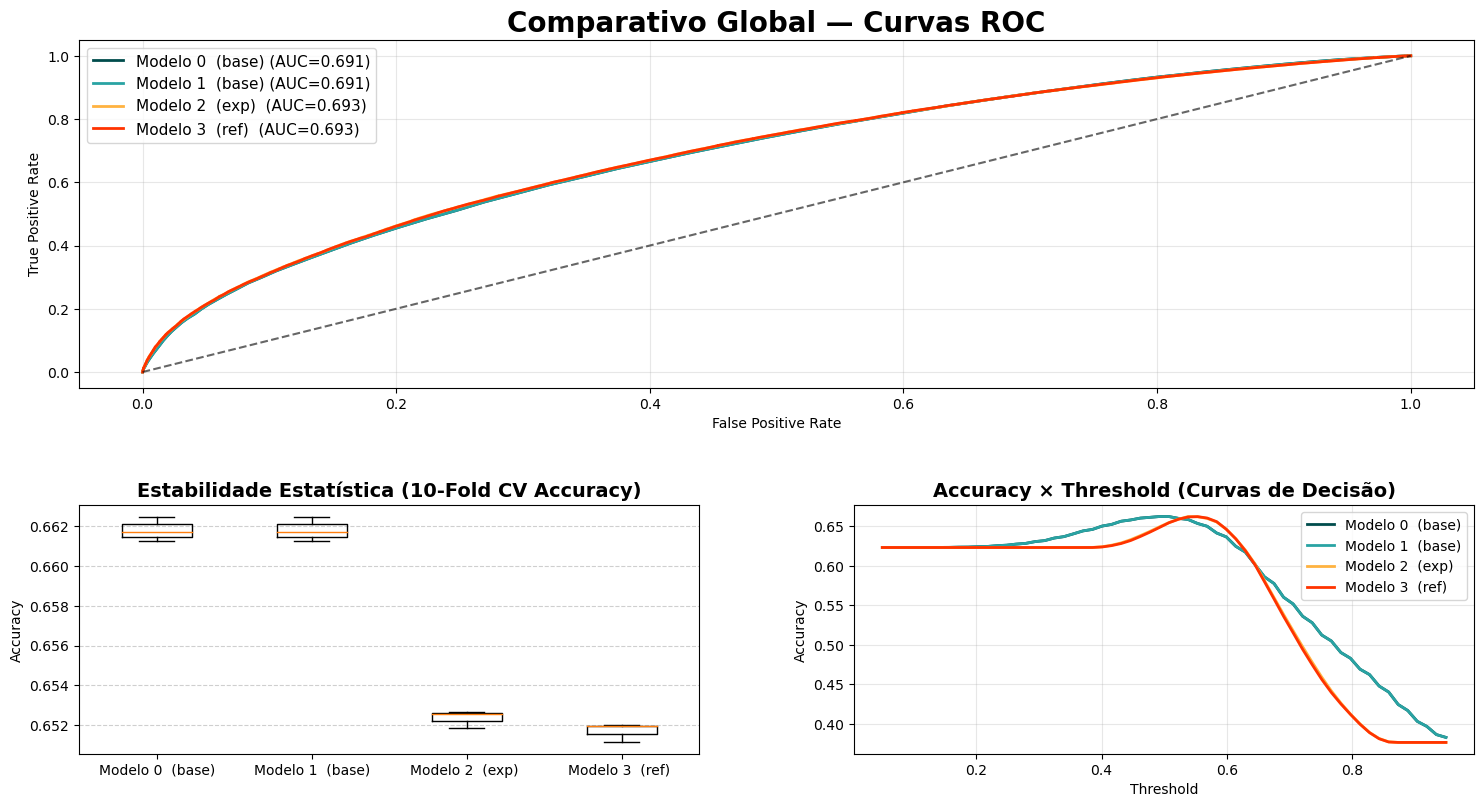

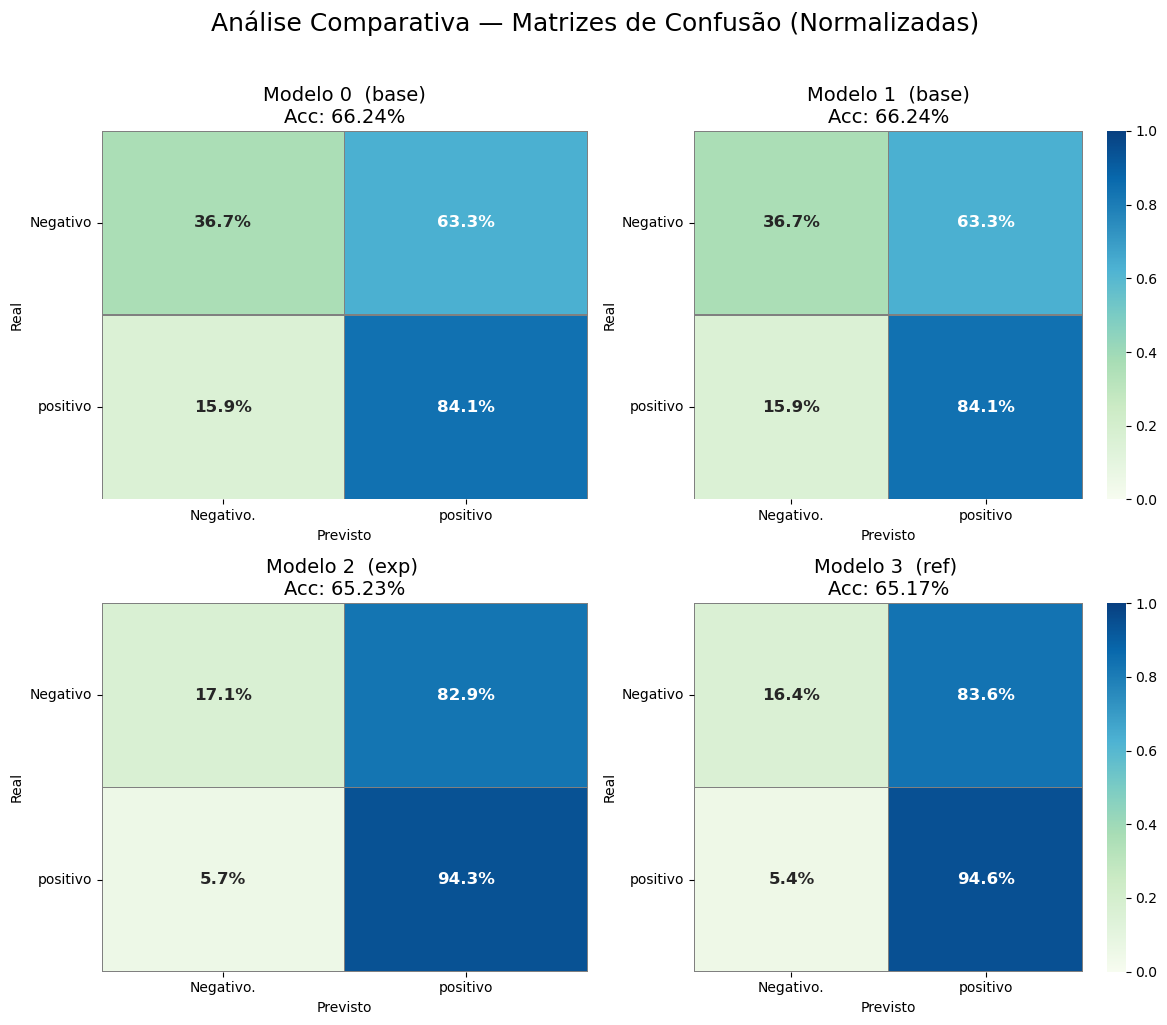

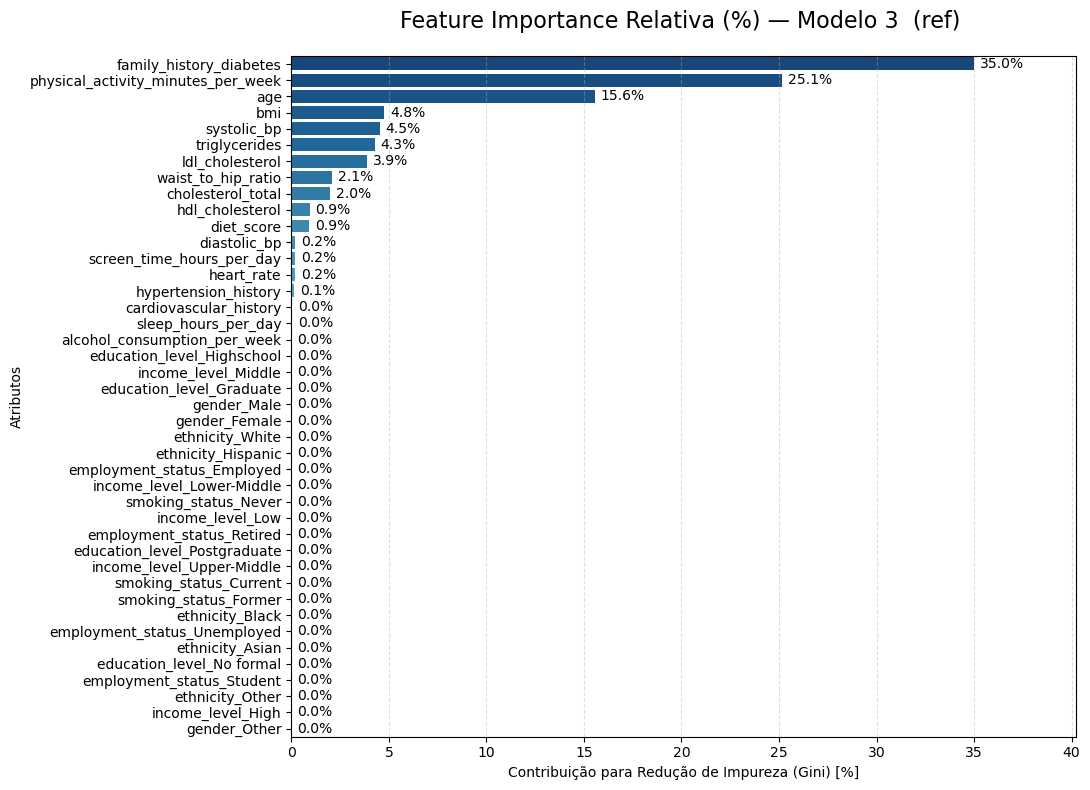


#Processo finalizado em: 13:50:20


In [15]:
#plotagem dos resultados
importances=model_evaluation_grid(
    models_list=models_list,
    X_test=X_val,
    y_test=y_val,
    best_model_pipeline=W[1],
    best_model_name=W[0]
)